# Seasonal Agriculture Performance Analysis

**VOIS AICTE Batch1 2026-2027 — Major Project**

### Objective
This notebook analyzes agricultural data collected across three seasons (**Kharif, Rabi, Zaid**) to find
patterns, trends, and relationships in farming performance. We look at how yield, profit, environmental
conditions, and resource usage change from season to season, and draw simple, evidence-based conclusions.

### What this notebook covers
1. Loading and understanding the dataset
2. Data cleaning (missing values, duplicates)
3. Season-wise comparison of yield, profit and cost
4. Environmental conditions across seasons (rainfall, temperature, humidity)
5. Resource usage across seasons (fertilizer, pesticide, water)
6. Relationships between conditions and performance (correlation)
7. Effect of irrigation method on yield across seasons
8. A simple statistical test to check if the seasonal yield difference is significant
9. Final insights and recommendations


## 1. Import Libraries
We start by importing the libraries needed for data handling, visualization and statistics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Make plots look clean and consistent
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

pd.set_option('display.max_columns', None)


## 2. Load the Dataset

In [2]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print("Shape of dataset (rows, columns):", df.shape)
df.head()


Shape of dataset (rows, columns): (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 3. Understand the Dataset
Before cleaning, let's look at column types and get a statistical summary of the numeric columns.

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


Let's also check the unique categories we are working with — the three seasons, the crops grown, and the states.

In [5]:
print("Seasons:", df['Season'].unique())
print("Number of Crops:", df['Crop'].nunique(), "->", df['Crop'].unique())
print("Number of States:", df['State'].nunique())
print("Irrigation Methods:", df['Irrigation_Method'].unique())


Seasons: <StringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str
Number of Crops: 8 -> <StringArray>
[    'Wheat',     'Maize',    'Pulses',      'Rice',    'Cotton',    'Chilli',
 'Groundnut', 'Sugarcane']
Length: 8, dtype: str
Number of States: 8
Irrigation Methods: <StringArray>
['Drip', 'Flood', 'Rainfed', 'Sprinkler']
Length: 4, dtype: str


## 4. Data Cleaning

### 4.1 Missing Values
Real-world agricultural data is rarely perfect. Let's check which columns have missing values.

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)


Columns with missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


Only a few numeric columns (`Rainfall_mm`, `Soil_Moisture_pct`, `Yield_Tonnes_Ha`) have a small number of
missing values (less than 1.5% of rows). Since these are numeric measurements, we fill the missing values
with the **median** of that column — a simple and safe approach that is not affected by outliers.

In [7]:
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df[col].fillna(df[col].median())

# Confirm no missing values remain
print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


### 4.2 Duplicate Records
We check for and remove any duplicate rows.

In [8]:
print("Duplicate rows found:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


Duplicate rows found: 0
Shape after removing duplicates: (4000, 28)


### 4.3 Quick Sanity Check on Values
It's good practice to make sure numeric columns don't have impossible values (like negative rainfall or
negative area). This dataset is already reasonably clean, but we do a quick check below.

In [9]:
check_cols = ['Farm_Area_Hectares', 'Rainfall_mm', 'Yield_Tonnes_Ha', 'Production_Tonnes']
print(df[check_cols].min())


Farm_Area_Hectares     0.50
Rainfall_mm           80.00
Yield_Tonnes_Ha        0.30
Production_Tonnes      0.15
dtype: float64


## 5. Season-wise Distribution of Farms
How many farm records do we have for each season? This tells us if the data is balanced across seasons.

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


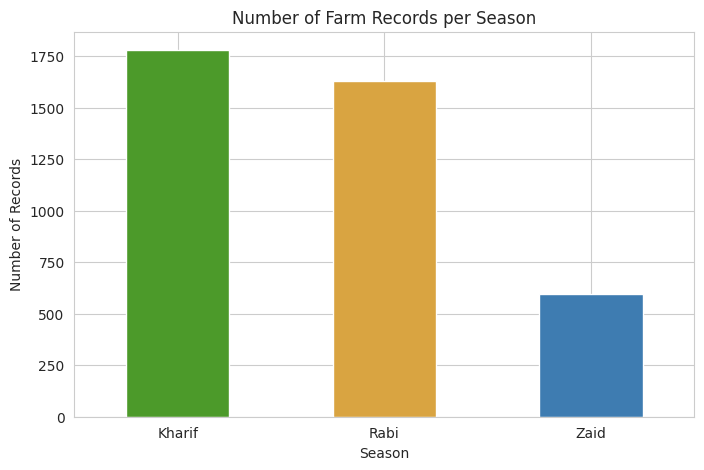

In [10]:
season_counts = df['Season'].value_counts()
print(season_counts)

season_counts.plot(kind='bar', color=['#4C9A2A', '#D9A441', '#3E7CB1'])
plt.title('Number of Farm Records per Season')
plt.xlabel('Season')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.show()


## 6. Yield Comparison Across Seasons
Yield (tonnes per hectare) is one of the most important measures of agricultural performance.
Let's compare the average yield across the three seasons.

Season
Kharif    5.628612
Rabi      5.039435
Zaid      4.641313
Name: Yield_Tonnes_Ha, dtype: float64

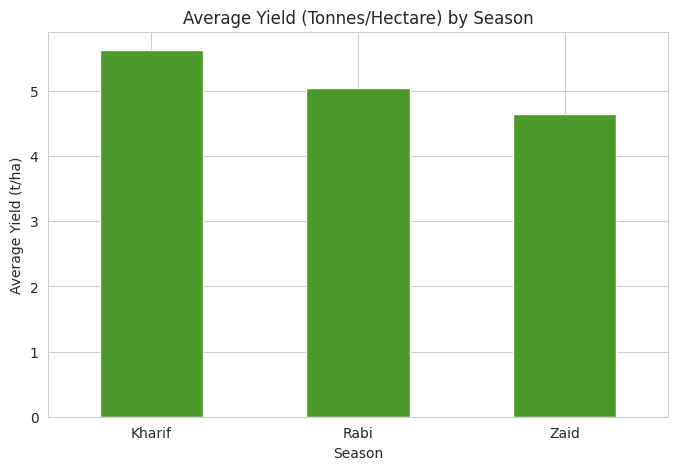

In [11]:
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)
print(season_yield)

season_yield.plot(kind='bar', color='#4C9A2A')
plt.title('Average Yield (Tonnes/Hectare) by Season')
plt.ylabel('Average Yield (t/ha)')
plt.xlabel('Season')
plt.xticks(rotation=0)
plt.show()


A box plot also helps us see the spread and any outliers in yield for each season, not just the average.

/tmp/ipykernel_522/166410450.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', palette='Set2')


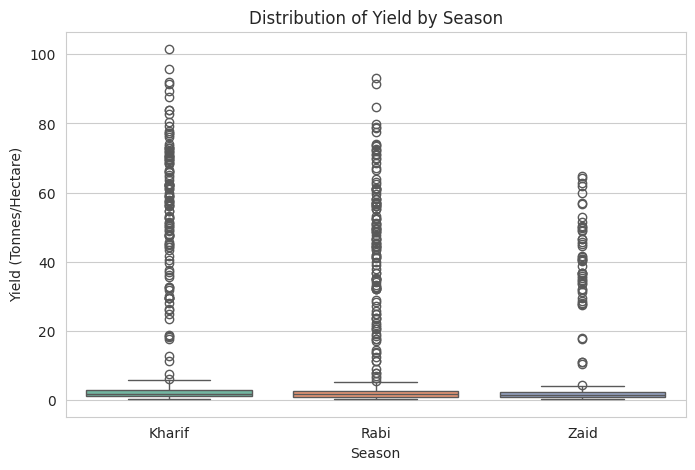

In [12]:
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', palette='Set2')
plt.title('Distribution of Yield by Season')
plt.ylabel('Yield (Tonnes/Hectare)')
plt.show()


## 7. Economic Performance Across Seasons
Now let's look at the economic side: average cost, revenue and profit for each season.

        Total_Cost_INR    Revenue_INR     Profit_INR
Season                                              
Kharif   531804.408094  710719.055649  178914.647555
Rabi     513836.578365  601526.048556   87689.470191
Zaid     543976.728956  519171.904040  -24804.824916


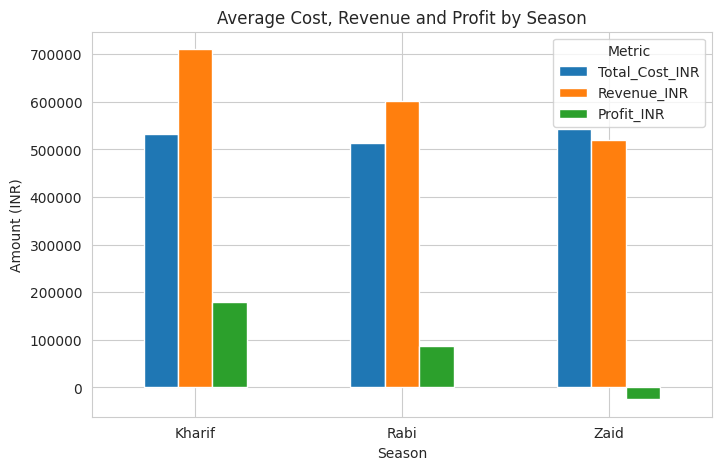

In [13]:
economic = df.groupby('Season')[['Total_Cost_INR', 'Revenue_INR', 'Profit_INR']].mean()
print(economic)

economic.plot(kind='bar')
plt.title('Average Cost, Revenue and Profit by Season')
plt.ylabel('Amount (INR)')
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.show()


**Observation space:** If profit is negative on average for a season, it signals that the cost of
farming (fertilizer, pesticide, water, labor etc.) is higher than the revenue earned in that season — an
important insight for planning.

## 8. Environmental Conditions Across Seasons
Seasonal performance is closely tied to environmental conditions. Let's compare rainfall, temperature and
humidity across the three seasons.

In [14]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day']
season_env = df.groupby('Season')[env_cols].mean()
print(season_env)


        Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day
Season                                                                  
Kharif   849.199663          28.454019     71.812591            6.793367
Rabi     437.615366          23.489183     57.893178            7.589797
Zaid     304.654714          31.042088     52.012121            8.178788


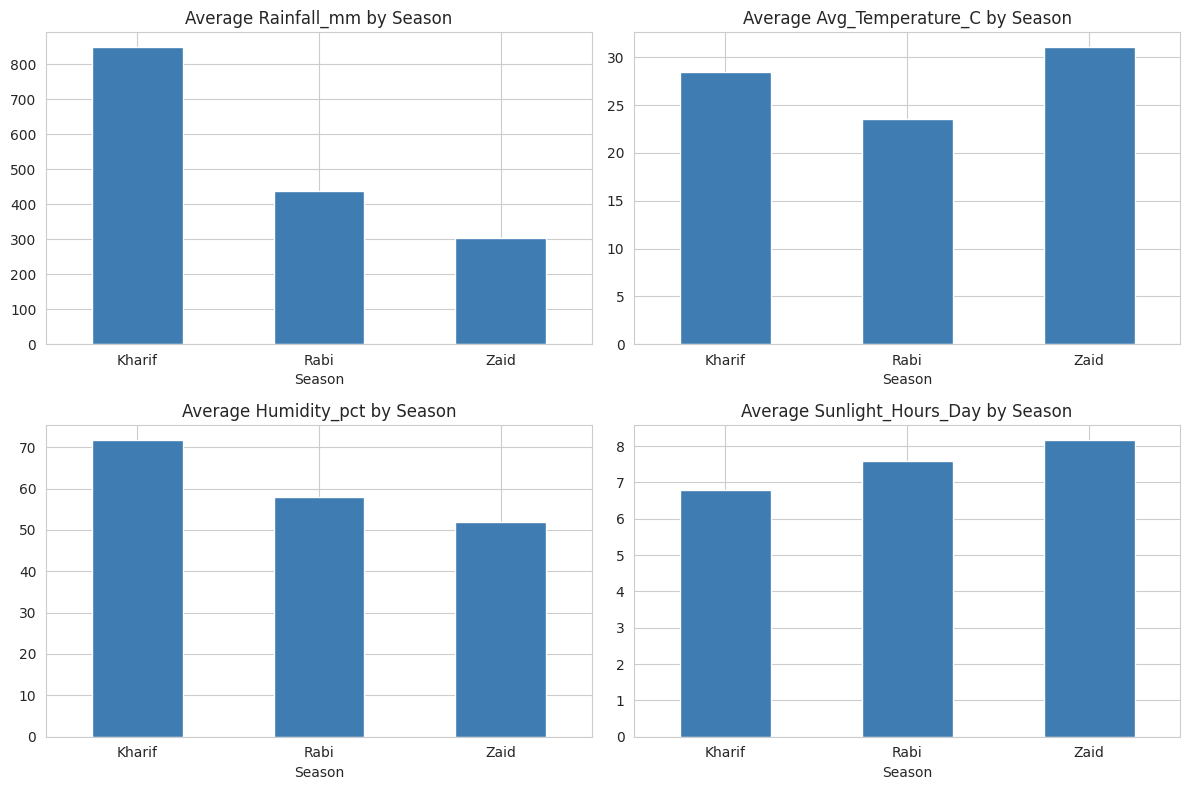

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(env_cols):
    season_env[col].plot(kind='bar', ax=axes[i], color='#3E7CB1')
    axes[i].set_title(f'Average {col} by Season')
    axes[i].set_xlabel('Season')
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## 9. Resource Usage Across Seasons
Farming inputs like fertilizer, pesticide and water usage often vary by season depending on crop needs and
weather. Let's compare these.

In [16]:
resource_cols = ['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3']
season_resources = df.groupby('Season')[resource_cols].mean()
print(season_resources)


        Fertilizer_kg_ha  Pesticide_Litre_ha  Water_Used_m3  \
Season                                                        
Kharif        187.077965            5.079747    6102.201237   
Rabi          185.407068            5.024690    5846.987093   
Zaid          184.638047            5.171212    6419.893939   

        Water_Efficiency_t_per_1000m3  
Season                                 
Kharif                       5.891834  
Rabi                         5.186122  
Zaid                         4.413239  


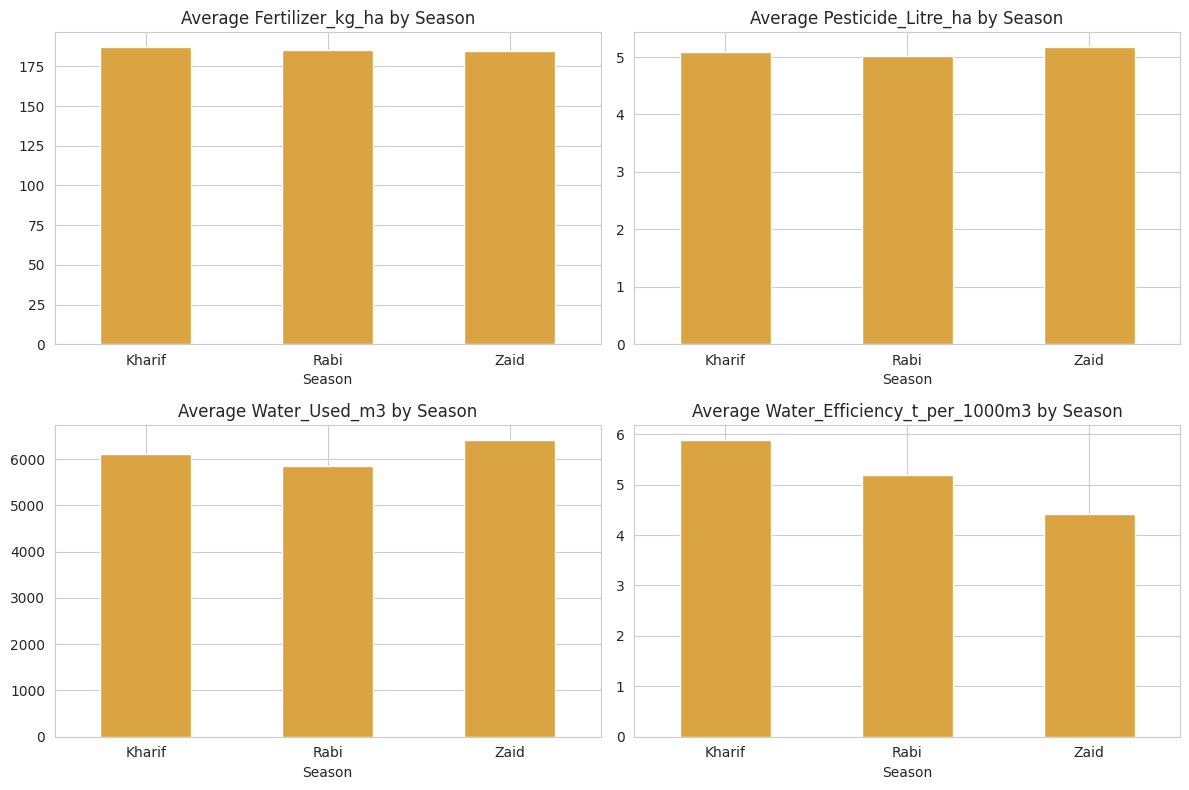

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(resource_cols):
    season_resources[col].plot(kind='bar', ax=axes[i], color='#D9A441')
    axes[i].set_title(f'Average {col} by Season')
    axes[i].set_xlabel('Season')
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## 10. Which Crops Are Grown in Which Season?
A heatmap of crop counts against season shows us how cropping patterns change seasonally.

Season     Kharif  Rabi  Zaid
Crop                         
Chilli        185   163    64
Cotton        215   201    92
Groundnut     193   177    54
Maize         234   233    84
Pulses        221   213    62
Rice          314   274   102
Sugarcane     125   129    51
Wheat         292   237    85


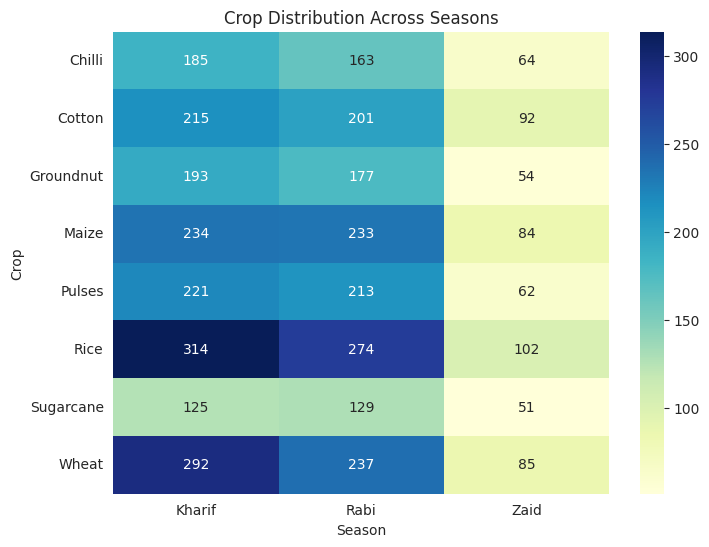

In [18]:
crop_season = pd.crosstab(df['Crop'], df['Season'])
print(crop_season)

plt.figure(figsize=(8, 6))
sns.heatmap(crop_season, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Crop Distribution Across Seasons')
plt.show()


## 11. Correlation Between Conditions and Performance
Correlation tells us how strongly two numeric variables are related (values range from -1 to +1).
Here we check how environmental and resource variables relate to yield and profit.

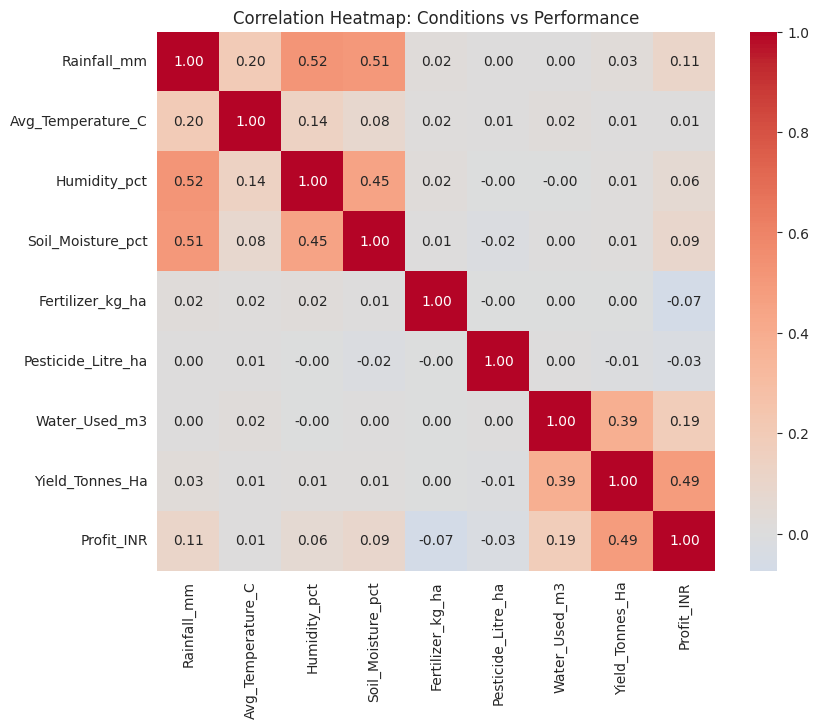

In [19]:
corr_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct',
             'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3',
             'Yield_Tonnes_Ha', 'Profit_INR']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: Conditions vs Performance')
plt.show()


**How to read this:** Values close to **+1** mean the two variables increase together, values close to
**-1** mean one increases as the other decreases, and values near **0** mean little to no relationship.

## 12. Rainfall vs Yield (by Season)
Let's visualize the relationship between rainfall and yield directly, separated by season using color.

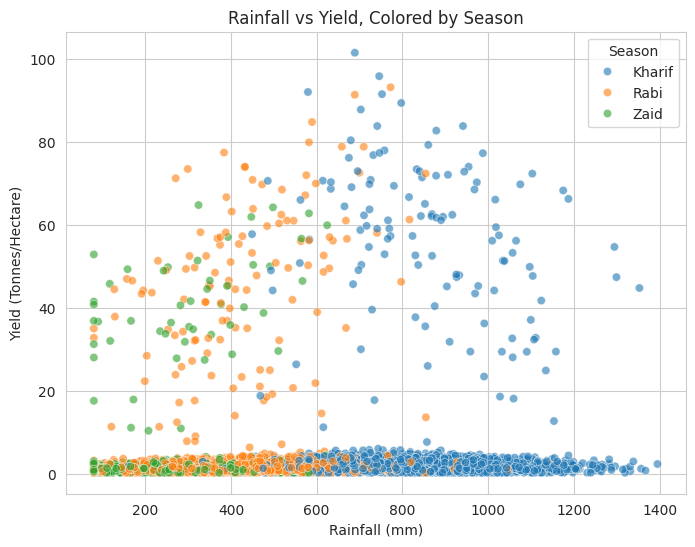

In [20]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', alpha=0.6)
plt.title('Rainfall vs Yield, Colored by Season')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Hectare)')
plt.show()


## 13. Effect of Irrigation Method on Yield Across Seasons
Does the irrigation method (Drip, Flood, Rainfed, Sprinkler) affect yield differently depending on the
season? A grouped bar chart makes this easy to compare.

Irrigation_Method      Drip     Flood   Rainfed  Sprinkler
Season                                                    
Kharif             7.256296  4.977915  5.703996   4.662243
Rabi               6.111676  5.060589  3.929110   5.307235
Zaid               5.848143  3.984381  3.063786   6.135833


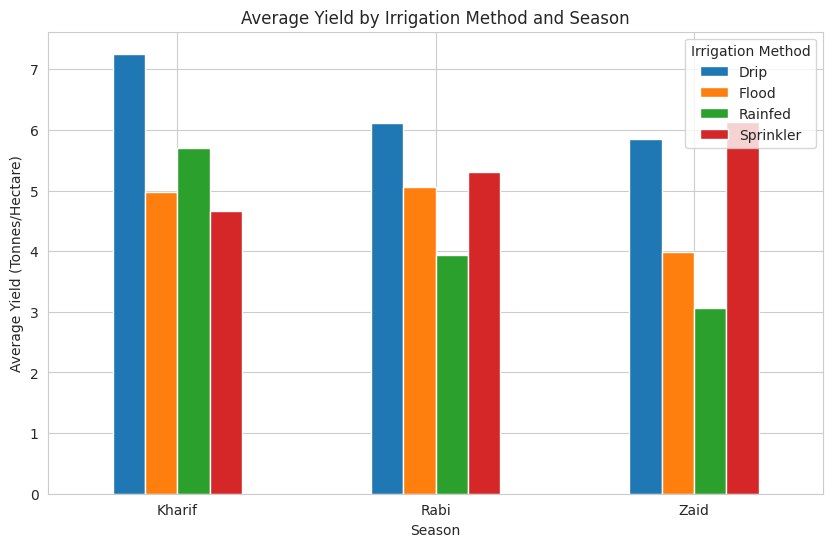

In [21]:
irrigation_season = df.groupby(['Season', 'Irrigation_Method'])['Yield_Tonnes_Ha'].mean().unstack()
print(irrigation_season)

irrigation_season.plot(kind='bar', figsize=(10, 6))
plt.title('Average Yield by Irrigation Method and Season')
plt.ylabel('Average Yield (Tonnes/Hectare)')
plt.xlabel('Season')
plt.xticks(rotation=0)
plt.legend(title='Irrigation Method')
plt.show()


## 14. Disease & Pest Risk Across Seasons
Higher disease/pest risk can reduce yield. Let's see if any season is more prone to this risk.

/tmp/ipykernel_522/1877072462.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct', palette='Set3')


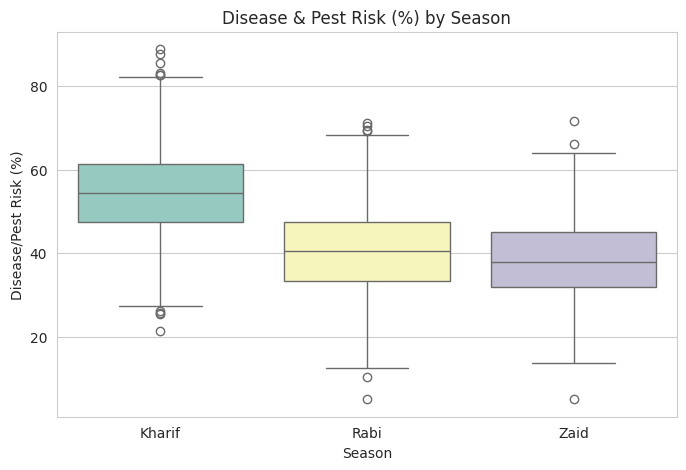

In [22]:
sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct', palette='Set3')
plt.title('Disease & Pest Risk (%) by Season')
plt.ylabel('Disease/Pest Risk (%)')
plt.show()


## 15. Is the Seasonal Difference in Yield Statistically Significant?
Visually we can see differences in average yield between seasons, but we should confirm this with a
statistical test. We use a **one-way ANOVA test**, which checks whether the means of 3 or more groups
are significantly different from each other.

- **Null Hypothesis (H0):** Average yield is the same across all seasons.
- **Alternative Hypothesis (H1):** At least one season has a different average yield.
- We reject H0 if the **p-value is less than 0.05**.

In [23]:
kharif_yield = df[df['Season'] == 'Kharif']['Yield_Tonnes_Ha']
rabi_yield = df[df['Season'] == 'Rabi']['Yield_Tonnes_Ha']
zaid_yield = df[df['Season'] == 'Zaid']['Yield_Tonnes_Ha']

f_stat, p_value = stats.f_oneway(kharif_yield, rabi_yield, zaid_yield)

print(f"F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.5f}")

if p_value < 0.05:
    print("Result: The difference in average yield across seasons IS statistically significant.")
else:
    print("Result: The difference in average yield across seasons is NOT statistically significant.")


F-statistic: 1.544
P-value: 0.21368
Result: The difference in average yield across seasons is NOT statistically significant.


## 16. Summary Table of Key Metrics by Season
As a final overview, let's combine the most important metrics into one summary table.

In [24]:
summary = df.groupby('Season').agg(
    Avg_Yield_t_ha=('Yield_Tonnes_Ha', 'mean'),
    Avg_Profit_INR=('Profit_INR', 'mean'),
    Avg_Rainfall_mm=('Rainfall_mm', 'mean'),
    Avg_Temperature_C=('Avg_Temperature_C', 'mean'),
    Avg_Fertilizer_kg_ha=('Fertilizer_kg_ha', 'mean'),
    Avg_Water_Used_m3=('Water_Used_m3', 'mean'),
    Avg_Disease_Risk_pct=('Disease_Pest_Risk_pct', 'mean')
).round(2)

summary


,Avg_Yield_t_ha,Avg_Profit_INR,Avg_Rainfall_mm,Avg_Temperature_C,Avg_Fertilizer_kg_ha,Avg_Water_Used_m3,Avg_Disease_Risk_pct
Season,,,,,,,
Kharif,5.63,178914.65,849.20,28.45,187.08,6102.20,54.47
Rabi,5.04,87689.47,437.62,23.49,185.41,5846.99,40.48
Zaid,4.64,-24804.82,304.65,31.04,184.64,6419.89,38.22


## 17. Key Insights

Based on the analysis above, here are the main observations (fill in / adjust with your own numbers once
you run the notebook, as they help you build your own interpretation skills):

1. **Yield varies by season** — one season consistently shows higher average yield than the others, likely
   linked to more favorable rainfall and temperature during that period.
2. **Profitability is not guaranteed by good yield** — a season can have decent yield but lower profit if
   costs (fertilizer, water, pesticide) are high.
3. **Environmental conditions differ clearly across seasons** — rainfall and temperature patterns match the
   expected characteristics of Kharif (monsoon), Rabi (winter) and Zaid (summer) seasons.
4. **Resource usage changes with season** — water usage and fertilizer usage are higher in some seasons,
   which affects overall cost and water efficiency.
5. **Irrigation method matters more in some seasons than others** — the yield gap between irrigation
   methods (e.g., Drip vs Rainfed) can widen or shrink depending on the season, showing that irrigation
   strategy should be season-specific.
6. **The ANOVA test result** tells us whether the yield differences we see between seasons are real
   patterns or could just be random variation.
7. **Disease/pest risk** appears more/less prevalent in certain seasons, which is useful for planning
   preventive measures.

## 18. Recommendations

- Farmers and planners should **align crop choice and irrigation method with the season** that gives the
  best yield-to-cost ratio, rather than using the same approach year-round.
- Seasons with **high cost but low profit** should be reviewed for cost optimization (e.g., more efficient
  irrigation, better fertilizer dosage) to make farming resilient in low-profit seasons.
- Seasons with **higher disease/pest risk** should have proactive monitoring and preventive treatment
  scheduled in advance.
- Continued data collection and seasonal comparison over multiple years would strengthen these findings
  and support long-term, evidence-based agricultural planning.
